# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


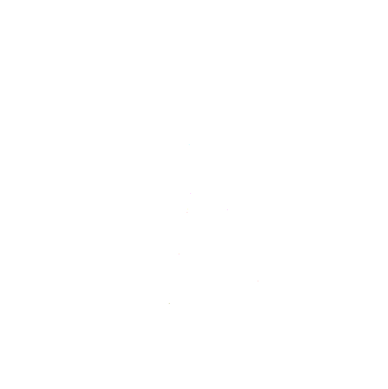

Threshold value: 50


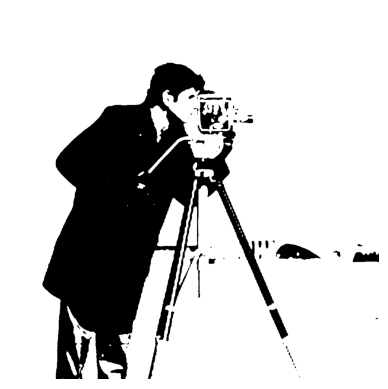

Threshold value: 100


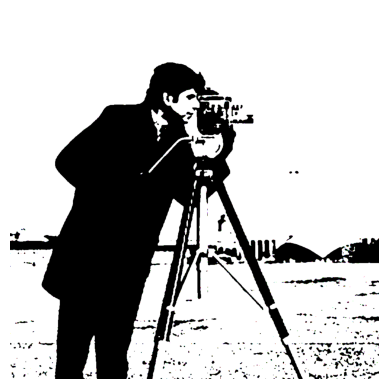

Threshold value: 150


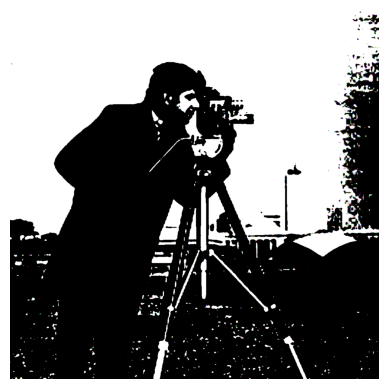

Threshold value: 200


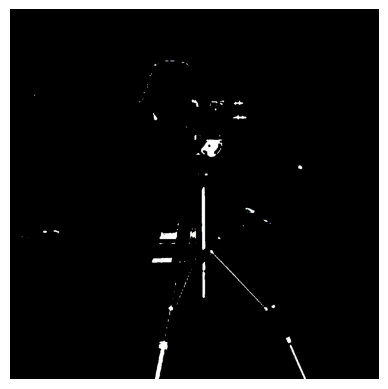

In [11]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
#img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)
img = cv2.imread('cameraman.png')

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    # returns two output: threshold value, resulting img
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY) # parameters: (input img, threshold, maximum value (values given to pixels greater than the threshold), method (how thresholding is performed))

    print(f"Threshold value: {threshold_value}")
    plt.imshow(thresh_img)
    plt.axis('off')
    plt.show()

Original Image: 


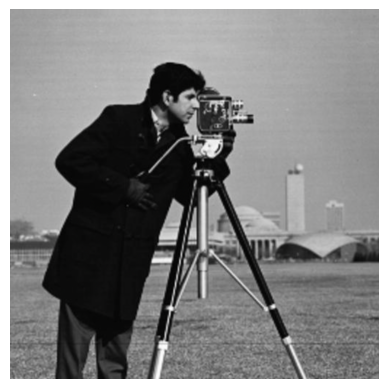

In [14]:
print("Original Image: ")
plt.axis("off")
plt.imshow(img)
plt.show()

## Histograms

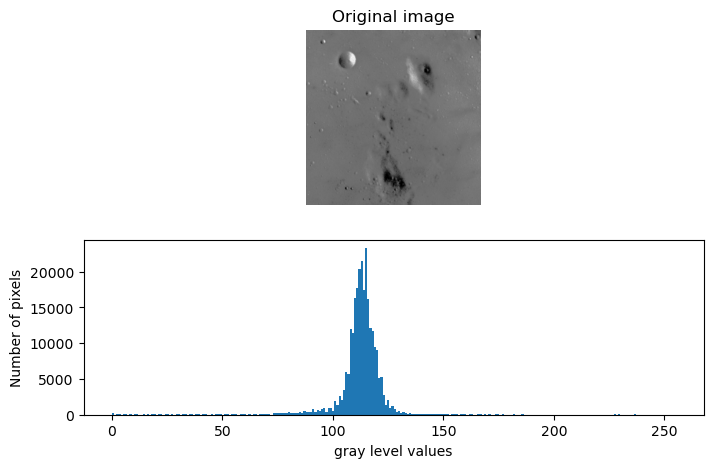

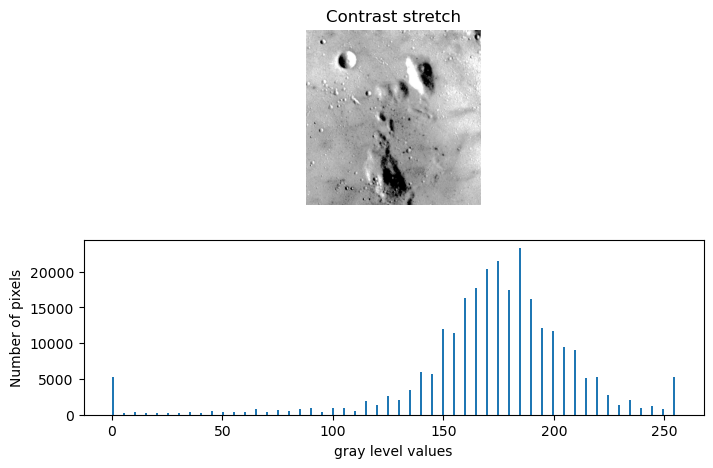

In [15]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


In [16]:
# Libraries
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure # provides functions for changing image intensity

### Task 1

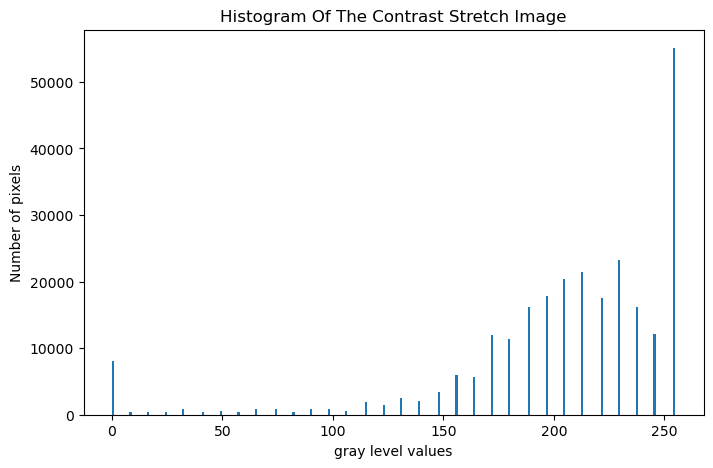

In [24]:
'''Using the same 'moon image' Rescale intensity values to include all the intensities that fall within the 
3rd and 80th percentiles, and plot the histogram'''

# Load the image
moon_img = data.moon()

# Rescale intensity values (3rd - 80th percentiles)
p3, p80 = np.percentile(moon_img, (3,80))
moon_rescaled = exposure.rescale_intensity(moon_img, in_range=(p3, p80))

# Plot the histogram
fig = plt.figure(figsize=(8, 5))
plt.hist(moon_rescaled.flat, bins = 256, range=(0, 255))
plt.title('Histogram Of The Contrast Stretch Image')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

### Task 2

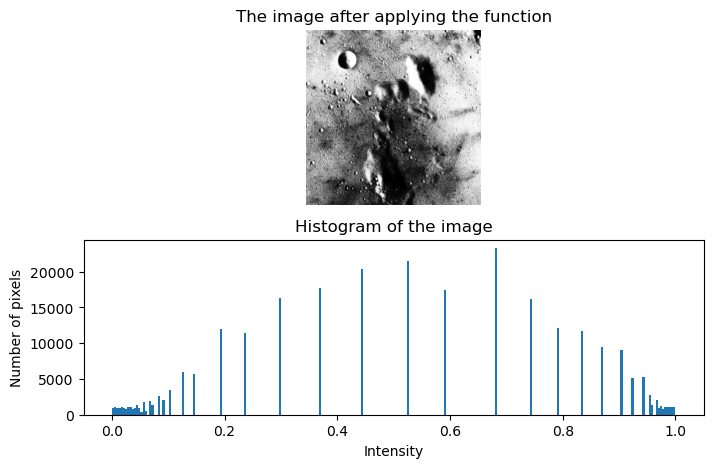

In [32]:
'''Using the same 'moon image' and the exposure.equalize_hist function,
display the image and the histogram of the image after flattening the histogram.'''

# Use the moon image with exposure.equalize_hist function
moon_equ = exposure.equalize_hist(moon_img) # return values between 0-1

# Display the image and its histogram
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(moon_equ, cmap='gray')
plt.title('The image after applying the function')
plt.axis('off')

fig.add_subplot(2,1,2)
plt.hist(moon_equ.flat, bins = 256, range=(0,1))
plt.title('Histogram of the image')
plt.xlabel('Intensity')
plt.ylabel('Number of pixels')
plt.show()

### Task 3

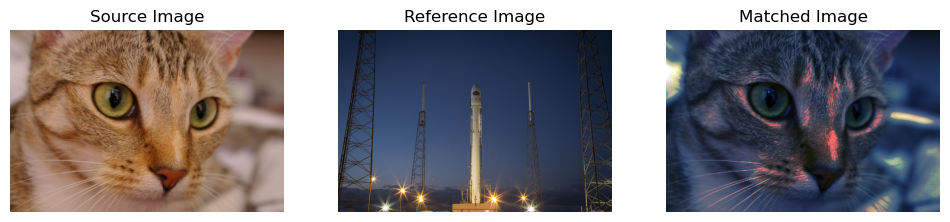

In [43]:
'''Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching'''

# Libraries & Images
from skimage.exposure import match_histograms
reference = data.rocket()
chelsea_img = data.chelsea()

# Matching histograms
matched = match_histograms(chelsea_img, reference, channel_axis=-1)

# Display images
fig = plt.figure(figsize=(12, 4))

fig.add_subplot(1, 3, 1)
plt.imshow(chelsea_img)
plt.title('Source Image')
plt.axis('off')

fig.add_subplot(1, 3, 2)
plt.imshow(reference)
plt.title('Reference Image')
plt.axis('off')

fig.add_subplot(1, 3, 3)
plt.imshow(matched)
plt.title('Matched Image')
plt.axis('off')

plt.show()